In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stochastic

In [21]:
stochastic.OrnsteinUhlenbeck()

Cointegration test - p-value: 0.2613
True beta: 1.2
Estimated hedge ratio: 0.9782

Average volatility ratio (vol_2/vol_1): 0.98

Saved visualization to pair_data.png

BACKTESTING POSITION SIZING STRATEGIES

STANDARD:
  Final Capital: $97,671.10
  Total Return: -2.33%
  Sharpe Ratio: -0.27
  Max Drawdown: -5.67%
  Number of Trades: 8

VOL ADJUSTED:
  Final Capital: $98,023.97
  Total Return: -1.98%
  Sharpe Ratio: -0.20
  Max Drawdown: -6.06%
  Number of Trades: 8

EQUAL RISK:
  Final Capital: $98,443.40
  Total Return: -1.56%
  Sharpe Ratio: -0.16
  Max Drawdown: -5.71%
  Number of Trades: 8


Saved backtest comparison to backtest_comparison.png

DETAILED ANALYSIS OF POSITION SIZING IMPACT

Simulating trade starting at day 289
Entry Z-score: 2.34
Vol ratio at entry: 0.98

POSITION SIZING COMPARISON:
----------------------------------------------------------------------

Standard (50/50 split):
  Asset 1 weight: 50.0% → $50,000
  Asset 2 weight: 50.0% → $50,000

Vol-Adjusted (inverse vo

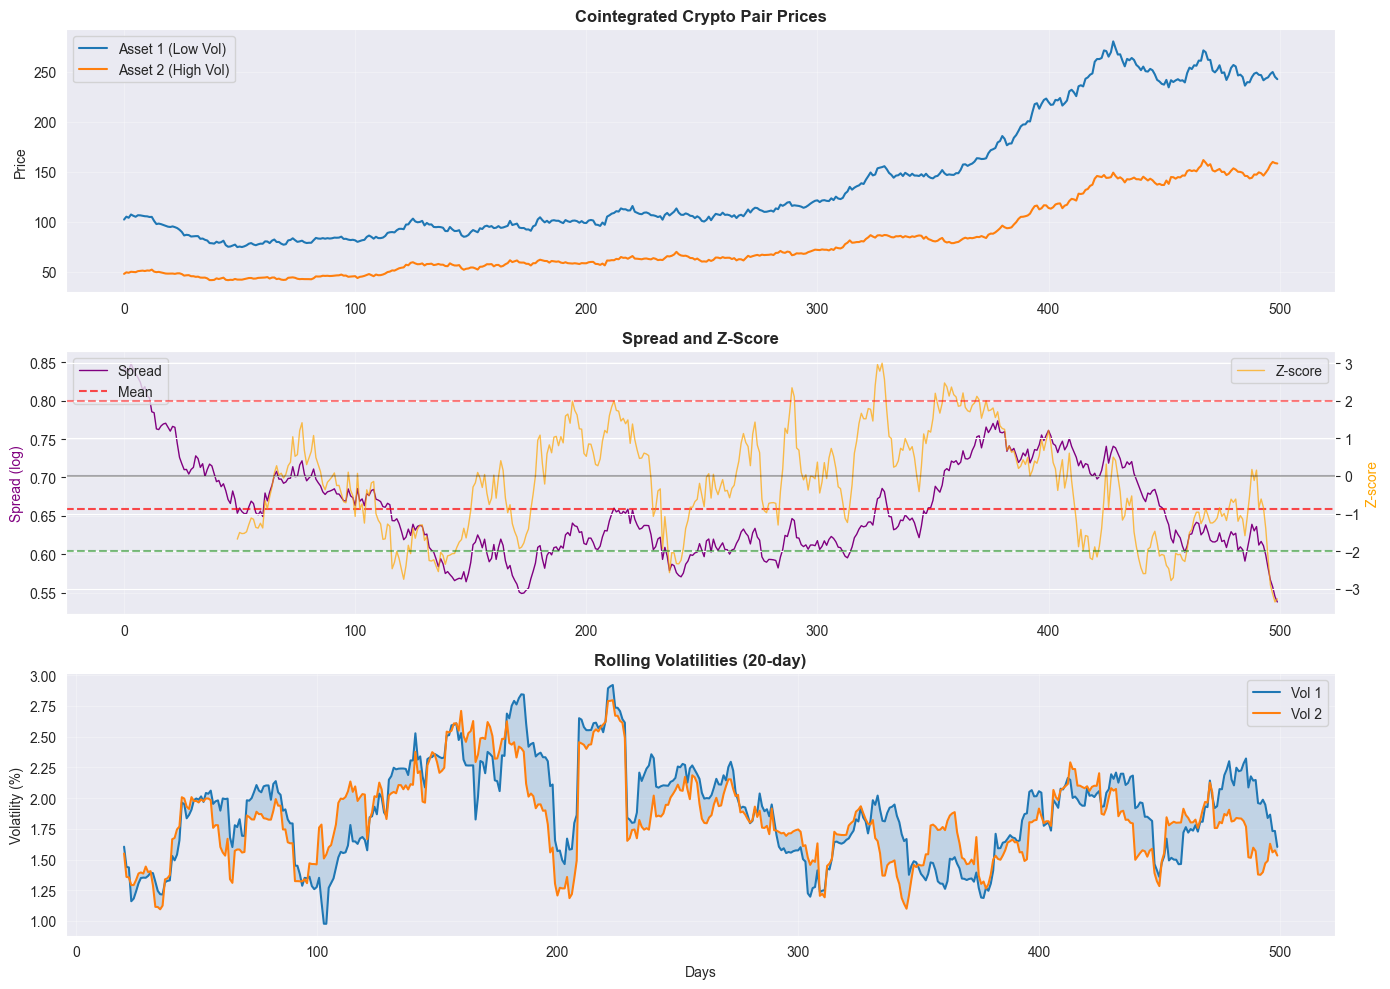

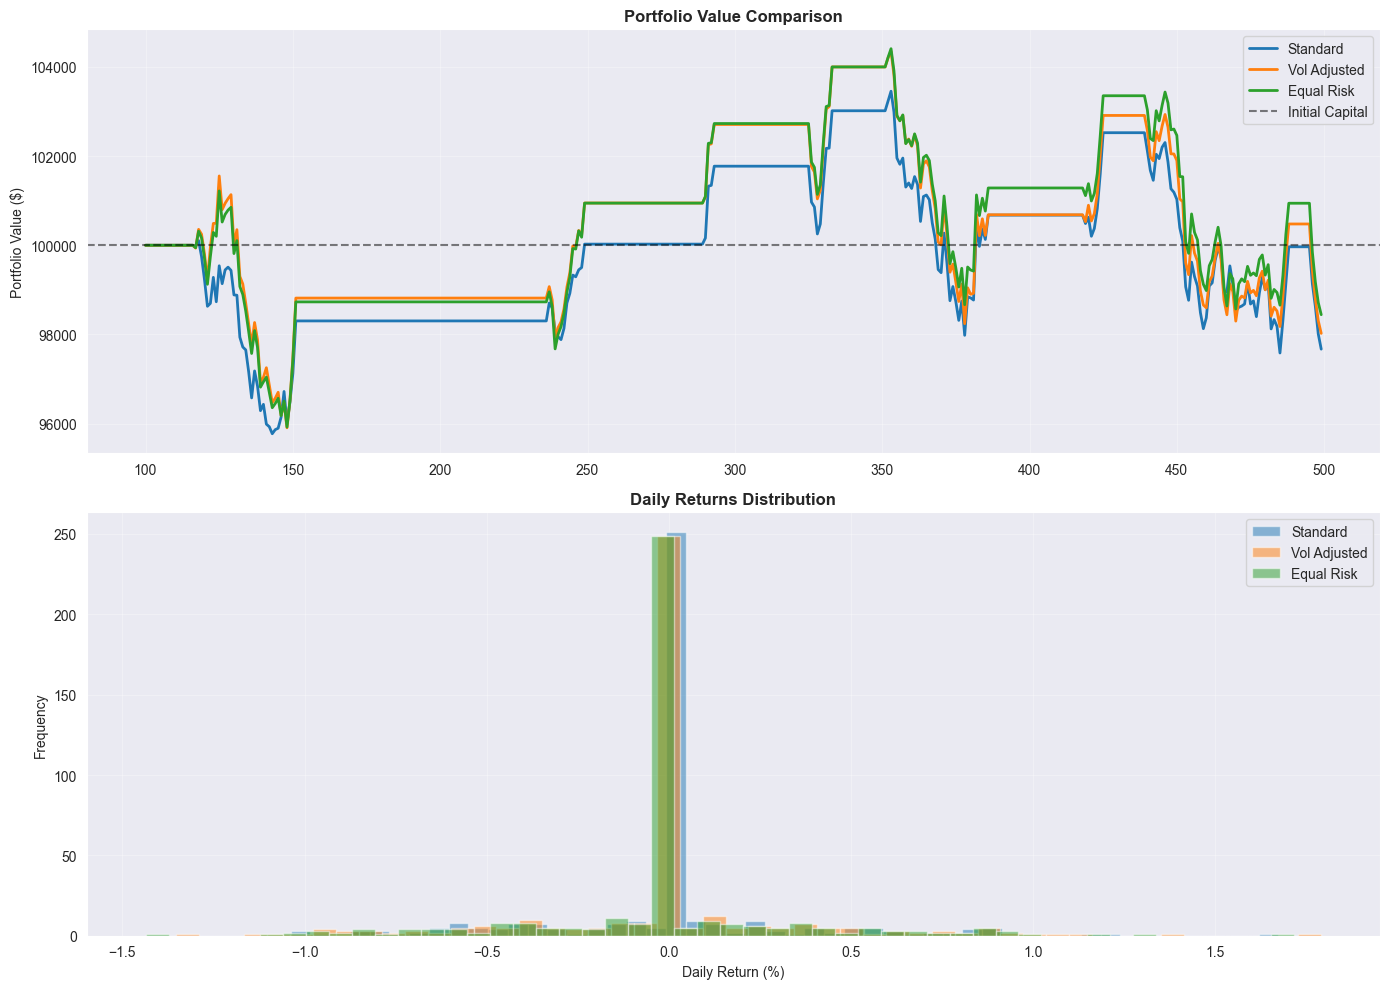

In [19]:
from statsmodels.tsa.stattools import coint
import seaborn as sns

np.random.seed(42)
sns.set_style("darkgrid")

# Generate synthetic cointegrated pair with asymmetric volatility
n_days = 500
t = np.arange(n_days)

# Common trend (market factor)
market = np.cumsum(np.random.normal(0.001, 0.02, n_days))

# Asset 1: lower volatility
drift_1 = 0.0005
vol_1 = 0.015  # 1.5% daily vol
noise_1 = np.random.normal(0, vol_1, n_days)
price_1 = 100 * np.exp(np.cumsum(drift_1 + 0.7 * np.diff(market, prepend=0) + noise_1))

# Asset 2: higher volatility (2x), cointegrated with asset 1
drift_2 = 0.0003
vol_2 = 0.030  # 3% daily vol (2x asset 1)
# Create cointegration relationship
beta_true = 1.2
noise_2 = np.random.normal(0, vol_2, n_days)
# Asset 2 follows asset 1 with some mean-reverting noise
log_price_2 = np.log(price_1) / beta_true + np.cumsum(noise_2 * 0.3)
price_2 = np.exp(log_price_2)

# Create DataFrame
df = pd.DataFrame(
    {
        "price_1": price_1,
        "price_2": price_2,
        "log_price_1": np.log(price_1),
        "log_price_2": np.log(price_2),
    }
)

# Calculate returns
df["ret_1"] = df["price_1"].pct_change()
df["ret_2"] = df["price_2"].pct_change()

# Test cointegration
score, pvalue, _ = coint(df["log_price_1"], df["log_price_2"])
print(f"Cointegration test - p-value: {pvalue:.4f}")
print(f"True beta: {beta_true}")

# Estimate hedge ratio via OLS
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
    df["log_price_2"], df["log_price_1"]
)
hedge_ratio = slope
print(f"Estimated hedge ratio: {hedge_ratio:.4f}")

# Calculate spread
df["spread"] = df["log_price_1"] - hedge_ratio * df["log_price_2"]
df["spread_zscore"] = (df["spread"] - df["spread"].rolling(50).mean()) / df[
    "spread"
].rolling(50).std()

# Calculate rolling volatilities
window = 20
df["vol_1"] = df["ret_1"].rolling(window).std()
df["vol_2"] = df["ret_2"].rolling(window).std()
df["vol_ratio"] = df["vol_2"] / df["vol_1"]

print(f"\nAverage volatility ratio (vol_2/vol_1): {df['vol_ratio'].mean():.2f}")

# Visualize the data
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Prices
axes[0].plot(df.index, df["price_1"], label="Asset 1 (Low Vol)", linewidth=1.5)
axes[0].plot(df.index, df["price_2"], label="Asset 2 (High Vol)", linewidth=1.5)
axes[0].set_title("Cointegrated Crypto Pair Prices", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Price")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Spread and Z-score
ax_spread = axes[1]
ax_spread.plot(df.index, df["spread"], label="Spread", color="purple", linewidth=1)
ax_spread.axhline(
    df["spread"].mean(), color="red", linestyle="--", label="Mean", alpha=0.7
)
ax_spread.set_ylabel("Spread (log)", color="purple")
ax_spread.legend(loc="upper left")
ax_spread.grid(alpha=0.3)

ax_zscore = ax_spread.twinx()
ax_zscore.plot(
    df.index,
    df["spread_zscore"],
    label="Z-score",
    color="orange",
    linewidth=1,
    alpha=0.7,
)
ax_zscore.axhline(0, color="black", linestyle="-", alpha=0.3)
ax_zscore.axhline(2, color="red", linestyle="--", alpha=0.5)
ax_zscore.axhline(-2, color="green", linestyle="--", alpha=0.5)
ax_zscore.set_ylabel("Z-score", color="orange")
ax_zscore.legend(loc="upper right")
ax_zscore.set_title("Spread and Z-Score", fontsize=12, fontweight="bold")

# Rolling volatilities
axes[2].plot(df.index, df["vol_1"] * 100, label="Vol 1", linewidth=1.5)
axes[2].plot(df.index, df["vol_2"] * 100, label="Vol 2", linewidth=1.5)
axes[2].fill_between(df.index, df["vol_1"] * 100, df["vol_2"] * 100, alpha=0.2)
axes[2].set_title("Rolling Volatilities (20-day)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Volatility (%)")
axes[2].set_xlabel("Days")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pair_data.png", dpi=150, bbox_inches="tight")
print("\nSaved visualization to pair_data.png")

# Now simulate trading strategies with different position sizing methods
print("\n" + "=" * 70)
print("BACKTESTING POSITION SIZING STRATEGIES")
print("=" * 70)


def backtest_strategy(df, method="standard", initial_capital=100000):
    """
    Backtest pairs trading with different position sizing methods

    Methods:
    - 'standard': Use hedge ratio only
    - 'vol_adjusted': Weight by inverse volatility
    - 'equal_risk': Equal risk contribution from each leg
    """

    capital = initial_capital
    positions = []
    pnl_series = []

    entry_threshold = 2.0
    exit_threshold = 0.5

    position = None  # None, 'long_spread', 'short_spread'
    entry_price_1 = None
    entry_price_2 = None
    entry_capital = None

    for i in range(100, len(df)):  # Start after warmup period
        row = df.iloc[i]
        prev_row = df.iloc[i - 1]

        # Skip if we don't have vol data yet
        if pd.isna(row["vol_1"]) or pd.isna(row["vol_2"]):
            pnl_series.append(capital)
            continue

        # Position sizing based on method
        if method == "standard":
            # Standard: just use hedge ratio
            w1 = 0.5
            w2 = 0.5

        elif method == "vol_adjusted":
            # Weight inversely to volatility
            w1 = 1 / row["vol_1"]
            w2 = hedge_ratio / row["vol_2"]
            total = w1 + w2
            w1 = w1 / total
            w2 = w2 / total

        elif method == "equal_risk":
            # Equal risk contribution: weight by inverse vol and hedge ratio
            # This makes each leg contribute equally to portfolio variance
            vol_scaled_1 = row["vol_1"]
            vol_scaled_2 = row["vol_2"] * hedge_ratio
            w1 = vol_scaled_2 / (vol_scaled_1 + vol_scaled_2)
            w2 = vol_scaled_1 / (vol_scaled_1 + vol_scaled_2)

        # Entry signals
        if position is None:
            if row["spread_zscore"] > entry_threshold:
                # Spread too high: short spread (short asset 1, long asset 2)
                position = "short_spread"
                entry_price_1 = row["price_1"]
                entry_price_2 = row["price_2"]
                entry_capital = capital

                # Calculate position sizes
                capital_1 = capital * w1
                capital_2 = capital * w2
                pos_1 = -capital_1 / entry_price_1  # short
                pos_2 = capital_2 / entry_price_2  # long
                positions.append((i, position, pos_1, pos_2, w1, w2))

            elif row["spread_zscore"] < -entry_threshold:
                # Spread too low: long spread (long asset 1, short asset 2)
                position = "long_spread"
                entry_price_1 = row["price_1"]
                entry_price_2 = row["price_2"]
                entry_capital = capital

                capital_1 = capital * w1
                capital_2 = capital * w2
                pos_1 = capital_1 / entry_price_1  # long
                pos_2 = -capital_2 / entry_price_2  # short
                positions.append((i, position, pos_1, pos_2, w1, w2))

        # Exit signals
        elif position is not None:
            should_exit = abs(row["spread_zscore"]) < exit_threshold

            if should_exit:
                # Calculate P&L
                if position == "long_spread":
                    pnl_1 = (row["price_1"] - entry_price_1) * pos_1
                    pnl_2 = (row["price_2"] - entry_price_2) * pos_2
                else:  # short_spread
                    pnl_1 = (row["price_1"] - entry_price_1) * pos_1
                    pnl_2 = (row["price_2"] - entry_price_2) * pos_2

                total_pnl = pnl_1 + pnl_2
                capital += total_pnl

                position = None
                entry_price_1 = None
                entry_price_2 = None

        # Track current capital
        if position is not None:
            # Mark to market
            if position == "long_spread":
                unrealized_1 = (row["price_1"] - entry_price_1) * pos_1
                unrealized_2 = (row["price_2"] - entry_price_2) * pos_2
            else:
                unrealized_1 = (row["price_1"] - entry_price_1) * pos_1
                unrealized_2 = (row["price_2"] - entry_price_2) * pos_2

            current_capital = entry_capital + unrealized_1 + unrealized_2
        else:
            current_capital = capital

        pnl_series.append(current_capital)

    return pd.Series(pnl_series, index=df.index[100:]), positions


# Run backtests
results = {}
for method in ["standard", "vol_adjusted", "equal_risk"]:
    pnl, positions = backtest_strategy(df.copy(), method=method)
    results[method] = pnl

    total_return = (pnl.iloc[-1] / 100000 - 1) * 100
    sharpe = (pnl.pct_change().mean() / pnl.pct_change().std()) * np.sqrt(252)
    max_dd = ((pnl / pnl.cummax()) - 1).min() * 100

    print(f"\n{method.upper().replace('_', ' ')}:")
    print(f"  Final Capital: ${pnl.iloc[-1]:,.2f}")
    print(f"  Total Return: {total_return:.2f}%")
    print(f"  Sharpe Ratio: {sharpe:.2f}")
    print(f"  Max Drawdown: {max_dd:.2f}%")
    print(f"  Number of Trades: {len(positions)}")

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Equity curves
for method, pnl in results.items():
    label = method.replace("_", " ").title()
    axes[0].plot(pnl.index, pnl, label=label, linewidth=2)

axes[0].axhline(
    100000, color="black", linestyle="--", alpha=0.5, label="Initial Capital"
)
axes[0].set_title("Portfolio Value Comparison", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Returns distribution
for method, pnl in results.items():
    returns = pnl.pct_change().dropna()
    label = method.replace("_", " ").title()
    axes[1].hist(returns * 100, bins=50, alpha=0.5, label=label)

axes[1].set_title("Daily Returns Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Daily Return (%)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("backtest_comparison.png", dpi=150, bbox_inches="tight")
print("\n\nSaved backtest comparison to backtest_comparison.png")

# Analyze a specific trade to show the difference
print("\n" + "=" * 70)
print("DETAILED ANALYSIS OF POSITION SIZING IMPACT")
print("=" * 70)

# Find a period with high spread and simulate one trade
high_spread_idx = (
    df[df["spread_zscore"] > 2].index[0]
    if len(df[df["spread_zscore"] > 2]) > 0
    else 150
)
trade_period = df.loc[high_spread_idx : high_spread_idx + 50].copy()

print(f"\nSimulating trade starting at day {high_spread_idx}")
print(f"Entry Z-score: {trade_period['spread_zscore'].iloc[0]:.2f}")
print(f"Vol ratio at entry: {trade_period['vol_ratio'].iloc[0]:.2f}")

# Compare position sizing
row = trade_period.iloc[0]
capital = 100000

print("\nPOSITION SIZING COMPARISON:")
print("-" * 70)

# Standard method
w1_std = 0.5
w2_std = 0.5
print("\nStandard (50/50 split):")
print(f"  Asset 1 weight: {w1_std:.1%} → ${capital * w1_std:,.0f}")
print(f"  Asset 2 weight: {w2_std:.1%} → ${capital * w2_std:,.0f}")

# Vol adjusted
w1_vol = 1 / row["vol_1"]
w2_vol = hedge_ratio / row["vol_2"]
total = w1_vol + w2_vol
w1_vol = w1_vol / total
w2_vol = w2_vol / total
print("\nVol-Adjusted (inverse volatility):")
print(f"  Asset 1 weight: {w1_vol:.1%} → ${capital * w1_vol:,.0f}")
print(f"  Asset 2 weight: {w2_vol:.1%} → ${capital * w2_vol:,.0f}")
print(f"  → Allocates {w1_vol / w2_vol:.2f}x more to low-vol asset")

# Equal risk
vol_scaled_1 = row["vol_1"]
vol_scaled_2 = row["vol_2"] * hedge_ratio
w1_eq = vol_scaled_2 / (vol_scaled_1 + vol_scaled_2)
w2_eq = vol_scaled_1 / (vol_scaled_1 + vol_scaled_2)
print("\nEqual Risk Contribution:")
print(f"  Asset 1 weight: {w1_eq:.1%} → ${capital * w1_eq:,.0f}")
print(f"  Asset 2 weight: {w2_eq:.1%} → ${capital * w2_eq:,.0f}")
print("  → Balances risk contribution from each leg")

plt.show()

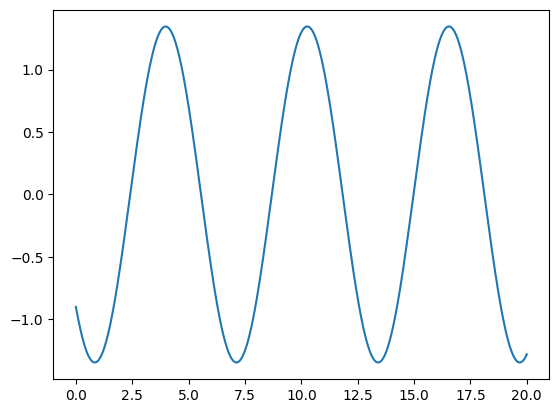

In [12]:
N = 1000
X = np.linspace(0, 20, N)
y_1 = 0.9 * np.sin(X - 0.5 * np.pi)
y_2 = np.sin(X)
plt.plot(X, y_1 - y_2)